# Demonstration of the preprocessing code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

from load_dataset import CustomDatasetLoader
from image_duplicates import RemoveDuplicates
from blurred_images import RemoveBlurredFaces

In [2]:
MAX_DATA = 2000

emotion_map = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "suprise",
}

loader = CustomDatasetLoader(csv_path="../format_datasets/dataset.csv", img_path="../format_datasets/dataset/")
images, labels = loader.load_dataset(max_samples=MAX_DATA)

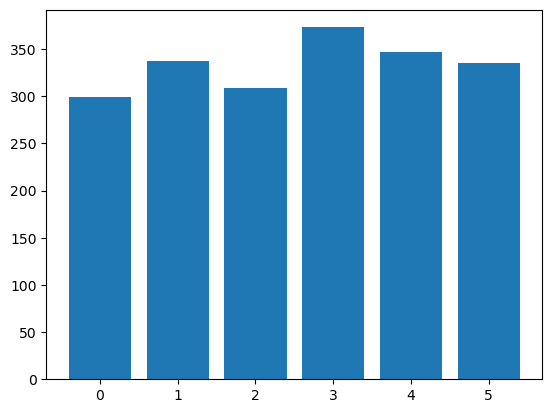

In [3]:
unique_labels, label_count = np.unique(labels, return_counts=True)
plt.bar(unique_labels, label_count)
plt.show()

## Blurry image removal

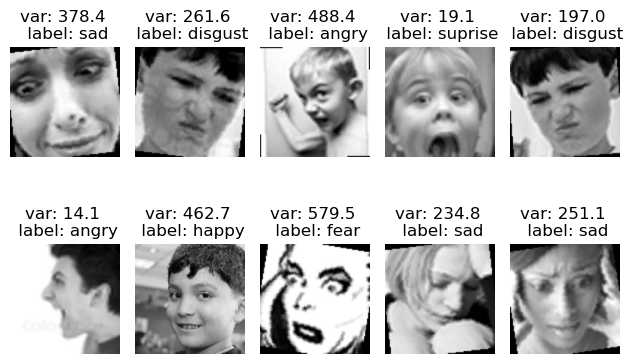

In [4]:
for i in range(10):
    image = images[i]
    label = labels[i]

    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

In [5]:
blur_handler = RemoveBlurredFaces()
sharp_images, proc_labels = blur_handler.process(images[:10], labels[:10], threshold = 200.0)

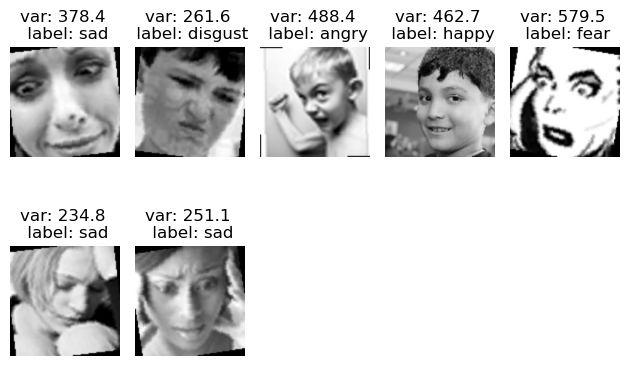

In [6]:
for i in range(len(sharp_images)):
    image = sharp_images[i]
    label = proc_labels[i]
    
    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

## Testing sharpening

In [7]:
sharpening_kernel = np.array([
    [0, -1, 0],
    [-1, 7, -1],
    [0, -1, 0]
])

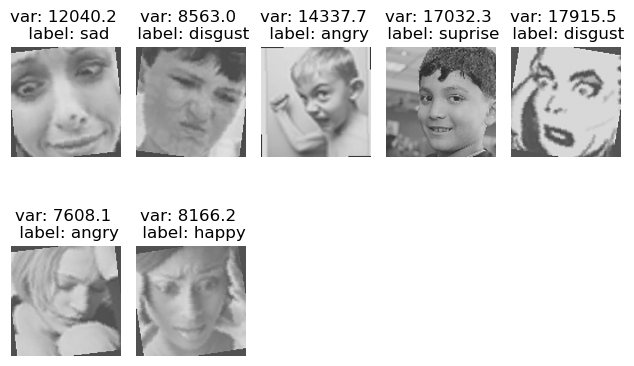

In [8]:
for i, image in enumerate(sharp_images):
    image = cv.filter2D(image, cv.CV_64F, kernel=sharpening_kernel)
    label = labels[i]
    
    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

## Removing identical/similar images

In [13]:
chosen_images = [
    images[0],
    images[1],
    images[1],
    images[2],
    images[0],
]
chosen_images = np.array(chosen_images)

chosen_labels = [
    labels[0],
    labels[1],
    labels[1],
    labels[2],
    labels[0],
]
chosen_labels = np.array(chosen_labels)

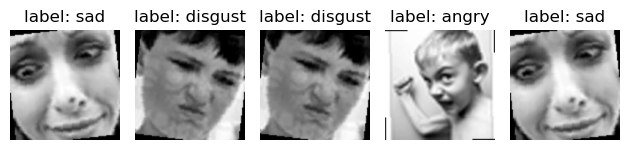

In [14]:

for i, image in enumerate(chosen_images):
    label = chosen_labels[i]

    plt.tight_layout()
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"label: {emotion_map[label]}")
    ax.axis("off")


plt.show()


In [15]:
duplicate_handler = RemoveDuplicates()
transformed_images, transformed_labels = duplicate_handler.process(chosen_images, chosen_labels)

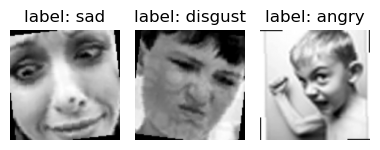

In [16]:
for i, image in enumerate(transformed_images):
    label = transformed_labels[i]

    plt.tight_layout()
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"label: {emotion_map[label]}")
    ax.axis("off")


plt.show()
